# Import libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load dataset

In [39]:
#Mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
flights = pd.read_csv('/content/drive/MyDrive/Data Sets/Airlines+Airports+Cancellation+Codes+&+Flights/flights.csv')


/tmp/ipykernel_9623/2447076942.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv('/content/drive/MyDrive/Data Sets/Airlines+Airports+Cancellation+Codes+&+Flights/flights.csv')


# Basic data exploration

## 1. Inspecting Data

In [41]:
# Showing the first few rows of the dataset to confirm structure.
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# Getting the summary stats (mean, min, max, quartiles) for numerical columns.
flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [43]:
# Summary info for the data types.
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [44]:
# Shape for how many rows and columns in the dataset
flights.shape

(5819079, 31)

## 2. Missing Values & Duplicates

In [45]:
# Check for missing values in the dataset
flights.isnull().sum()

,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,14721
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


In [46]:
# Check for duplicate rows in the dataset
flights.duplicated().sum()

np.int64(0)

# Data Visualisations

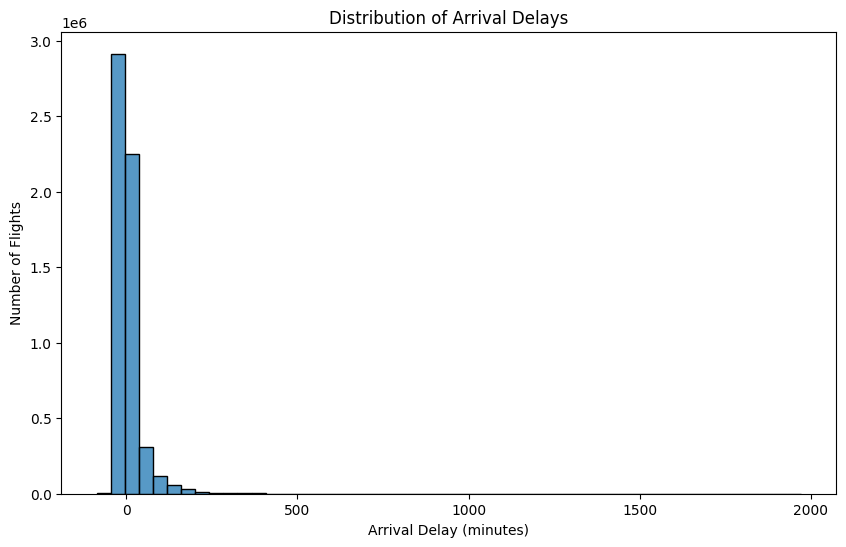

In [47]:
# Histogram Showing Distribution of Arrival Delay values
plt.figure(figsize=(10,6))
sns.histplot(flights['ARRIVAL_DELAY'], bins=50)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")
plt.show()

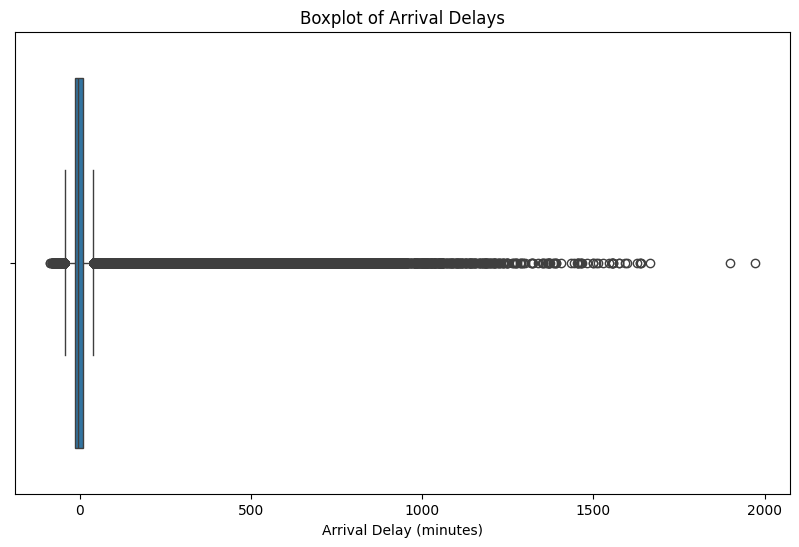

In [48]:
# Boxplot Showing Presense of Outliers in Arrival Delay Values
plt.figure(figsize=(10,6))
sns.boxplot(x=flights['ARRIVAL_DELAY'])
plt.title("Boxplot of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.show()

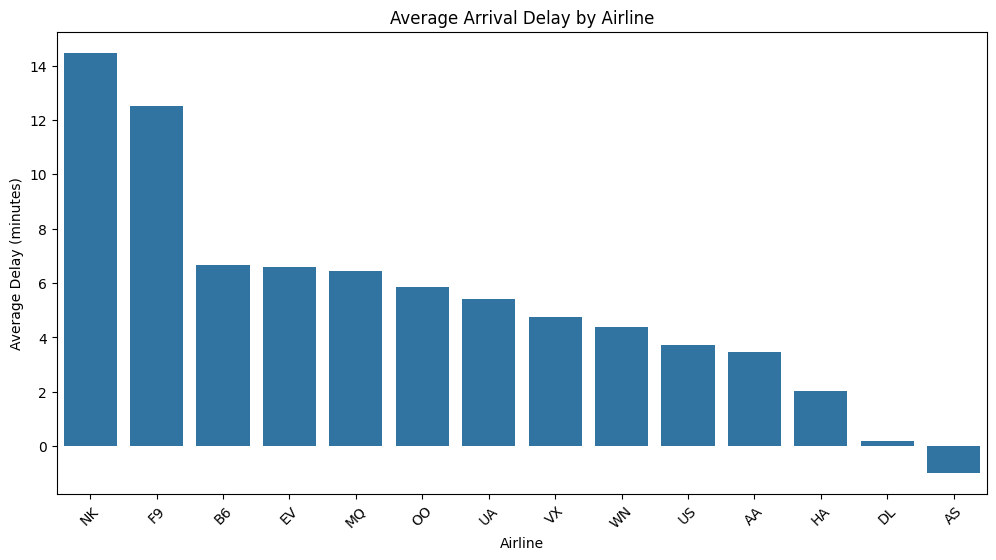

In [49]:
# Bar Chart of Average Delay by Airline
plt.figure(figsize=(12,6))
avg_delay = flights.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)
sns.barplot(x=avg_delay.index, y=avg_delay.values)
plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

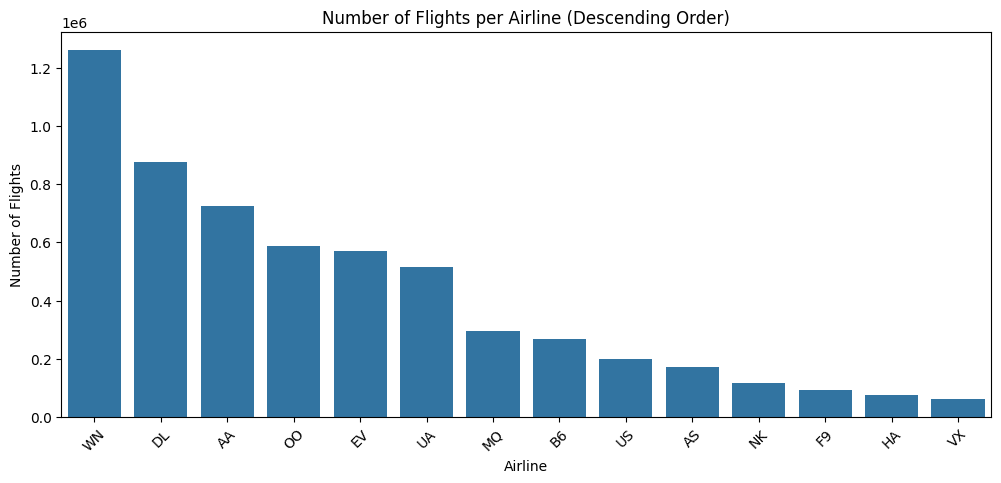

In [13]:
# Count plot of Flights per Airline

# Calculate counts per airline in order to sort values in descending order
airline_counts = flights['AIRLINE'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12,5))
sns.countplot(x='AIRLINE', data=flights, order=airline_counts.index)
plt.title("Number of Flights per Airline (Descending Order)")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

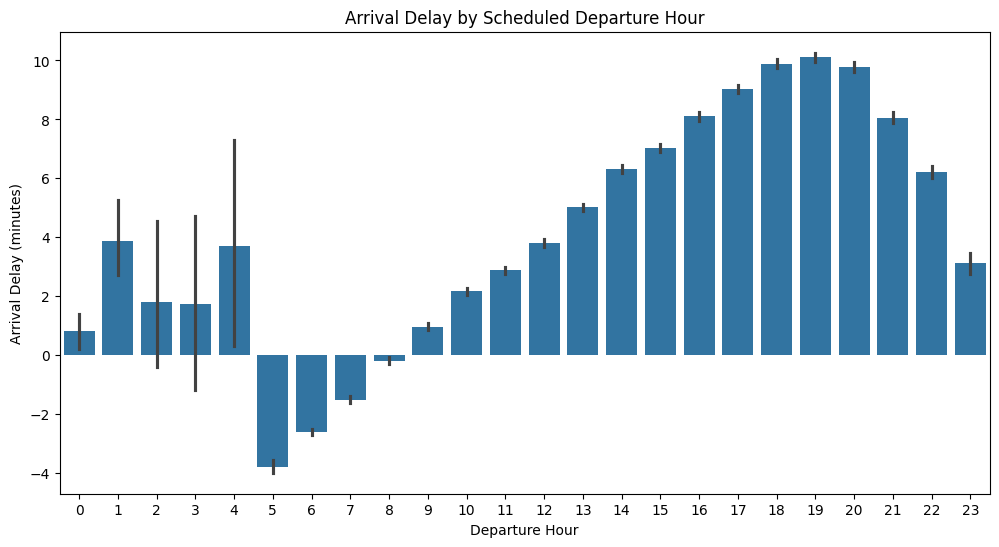

In [50]:
# A bar plot of Departure Hour vs. Arrival Delay

# Creating a column for Departure Hour as a derived feature
flights['DEPARTURE_HOUR'] = (flights['SCHEDULED_DEPARTURE'] // 100).astype(int)

plt.figure(figsize=(12,6))
sns.barplot(x='DEPARTURE_HOUR', y='ARRIVAL_DELAY', data=flights)
plt.title("Arrival Delay by Scheduled Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Arrival Delay (minutes)")
plt.show()

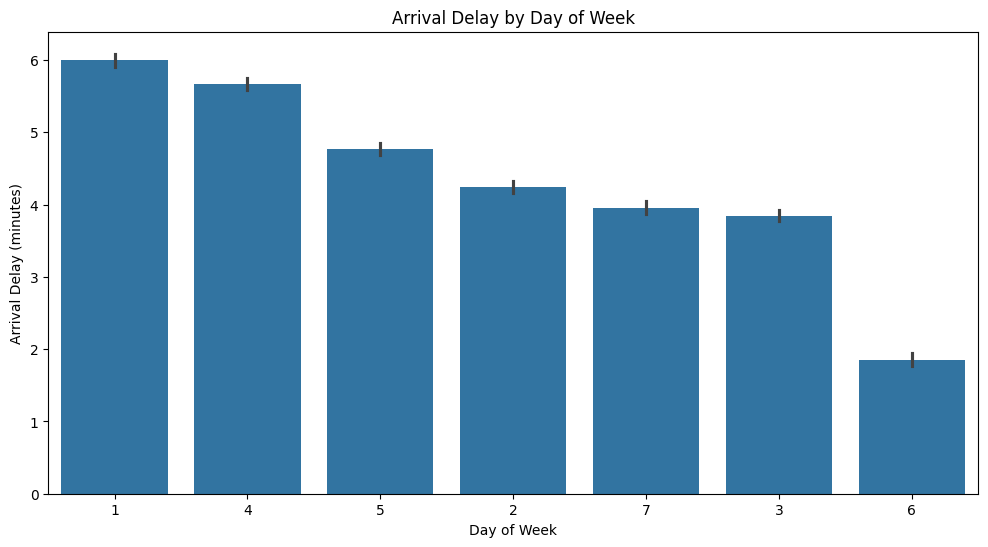

In [51]:
# Bar plot of Day of week vs Arrival Delay
# Calculating mean arrival delay per day of week
day_delay = flights.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='DAY_OF_WEEK', y='ARRIVAL_DELAY', data=flights, order=day_delay.index)
plt.title("Arrival Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Arrival Delay (minutes)")
plt.show()


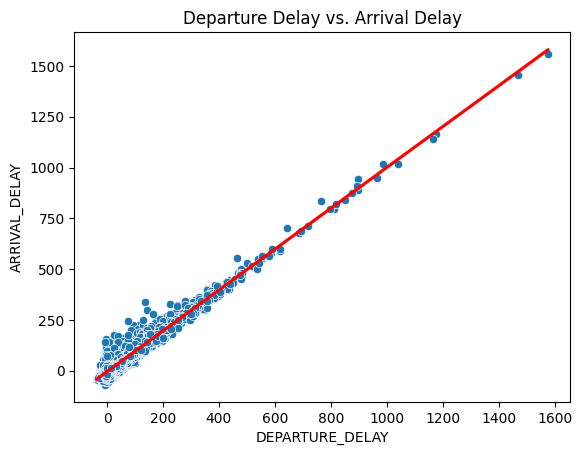

In [52]:
# A scatter plot of Departure Delay vs Arrival Delay

# Since the dataset was too huge, I created a sample for faster processing
sample = flights.sample(n=100000, random_state=42)

sns.scatterplot(x=sample['DEPARTURE_DELAY'], y=sample['ARRIVAL_DELAY'])
plt.title("Departure Delay vs. Arrival Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")

# Plotting the correlation line
sns.regplot(x=sample['DEPARTURE_DELAY'], y=sample['ARRIVAL_DELAY'], scatter=False, color='red')
plt.show()

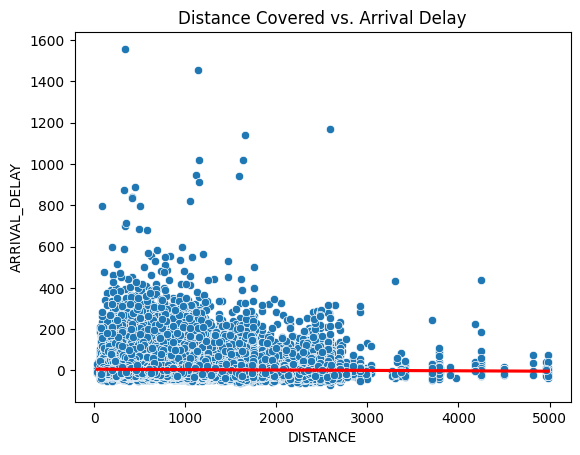

In [53]:
# A scatter plot of Distance covered vs Arrival Delay

# Since the dataset was too huge, I created a sample for faster processing
sample = flights.sample(n=100000, random_state=42)

sns.scatterplot(x=sample['DISTANCE'], y=sample['ARRIVAL_DELAY'])
plt.title("Distance Covered vs. Arrival Delay")
plt.xlabel("Distance (miles)")
plt.ylabel("Arrival Delay (minutes)")

# Plotting the correlation line
sns.regplot(x=sample['DISTANCE'], y=sample['ARRIVAL_DELAY'], scatter=False, color='red')
plt.show()

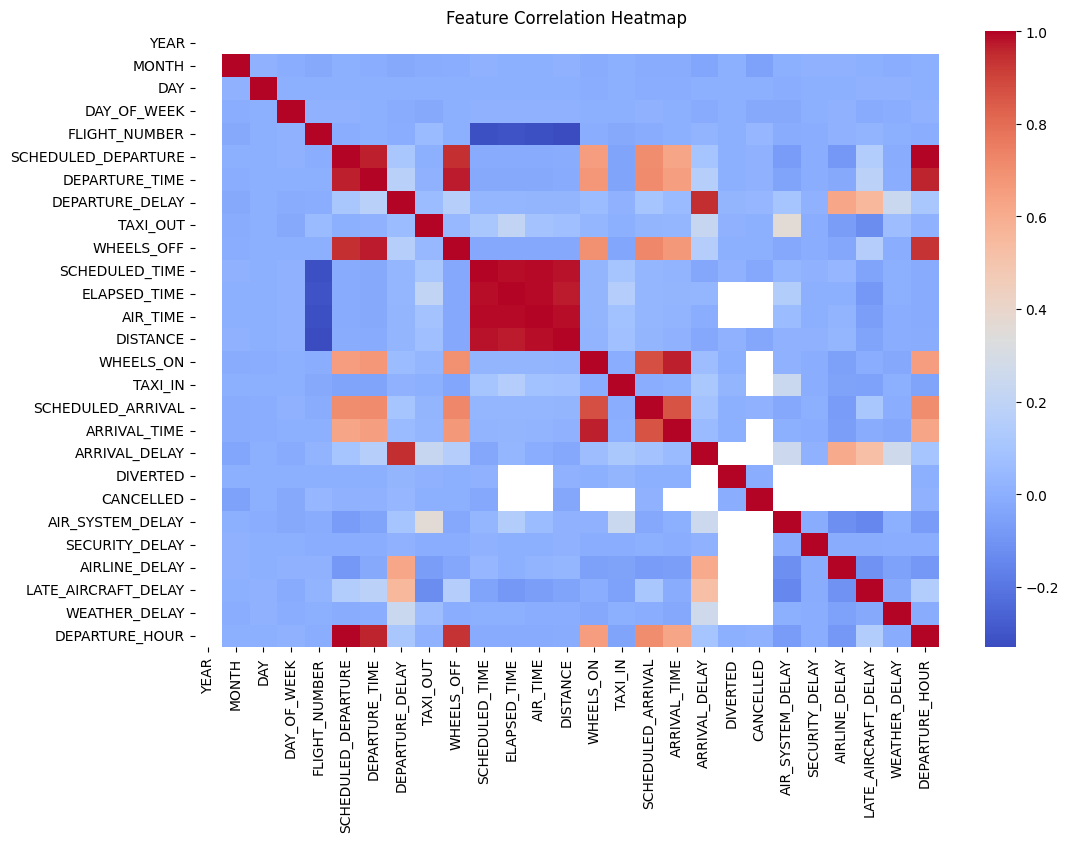

In [54]:
# Heatmap for the numeric columns Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(flights.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Machine Learning

## Data Cleaning & Preparation

In [55]:
# Handling missing values
# Dropping rows with missing target (ARRIVAL_DELAY)
flights = flights.dropna(subset=['ARRIVAL_DELAY'])

In [56]:
# Remove cancelled and diverted flights because we cannot get the arrival delay from them
flights = flights[(flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)]

print("Remaining rows:", flights.shape[0])

Remaining rows: 5714008


In [57]:
# Dropping unneccessary and redundant columns that will affect the model's performance
drop_cols = [
    'YEAR','FLIGHT_NUMBER','TAIL_NUMBER',
    'CANCELLED','DIVERTED','CANCELLATION_REASON',
    'ARRIVAL_TIME','DEPARTURE_TIME','WHEELS_ON','WHEELS_OFF',
    'AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY','WEATHER_DELAY'
]

flights = flights.drop(columns=[col for col in drop_cols if col in flights.columns])
print("Remaining columns:", flights.columns)

Remaining columns: Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_DELAY',
       'TAXI_OUT', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'DEPARTURE_HOUR'],
      dtype='object')


In [58]:
# Dropping leakage columns that reveal what happened during or after the flight (to avoid the model from “cheating” by using future knowledge)
drop_cols = ['DEPARTURE_DELAY','TAXI_OUT','AIR_TIME','TAXI_IN','ELAPSED_TIME']

flights = flights.drop(columns=[col for col in drop_cols if col in flights.columns])
print("Remaining columns:", flights.columns)

Remaining columns: Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME',
       'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'DEPARTURE_HOUR'],
      dtype='object')


In [59]:
# Airline and Airport features were dropped as a methodological choice to improve pipeline stability and interpretability

drop_cols = ['AIRLINE','DESTINATION_AIRPORT','ORIGIN_AIRPORT',]

flights = flights.drop(columns=[col for col in drop_cols if col in flights.columns])
print("Remaining columns:", flights.columns)

Remaining columns: Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME',
       'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'DEPARTURE_HOUR'],
      dtype='object')


In [60]:
# Checking what we have currently in the dataset
flights.head()

,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,DEPARTURE_HOUR
0,1,1,4,5,205.0,1448,430,-22.0,0
1,1,1,4,10,280.0,2330,750,-9.0,0
2,1,1,4,20,286.0,2296,806,5.0,0
3,1,1,4,20,285.0,2342,805,-9.0,0
4,1,1,4,25,235.0,1448,320,-21.0,0


In [61]:
# Checking for any missing values still in the dataset
flights.isnull().sum()

,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
SCHEDULED_DEPARTURE,0
SCHEDULED_TIME,0
DISTANCE,0
SCHEDULED_ARRIVAL,0
ARRIVAL_DELAY,0
DEPARTURE_HOUR,0


## Modeling & Evaluation

In [62]:
# Separating the dataset into training set (for learning) and testing set (for evaluation)

X = flights.drop(columns=['ARRIVAL_DELAY']) #features
y = flights['ARRIVAL_DELAY']                #target

# Saving the feature names before scaling to use in the Demo notebook
feature_names = X.columns.tolist()
joblib.dump(feature_names, "feature_names.pkl")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
# Scaling the numerical features to have them all on a comparable scale so that the larger‑scale features do not dominate the model’s learning process.

num_cols = ['MONTH','DAY','DAY_OF_WEEK','SCHEDULED_DEPARTURE','SCHEDULED_TIME','DISTANCE','SCHEDULED_ARRIVAL','DEPARTURE_HOUR']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [64]:
# Saving the scaler & num_cols list to use in the Demo notebook

joblib.dump(scaler, "scaler.pkl")
joblib.dump(num_cols, "num_cols.pkl")

['num_cols.pkl']

In [65]:
# Baseline model (Linear Regression)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# RMSE calculation
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 38.912111415290305
Linear Regression R²: 0.01360950373720371


In [66]:
y_pred_lr

array([8.50382481, 6.30943621, 3.62975574, ..., 6.64395522, 5.31156917,
       3.74416868])

In [67]:
# Random Forest
# This was trained on a smaller sample for faster processing
flights_sample = flights.sample(frac=0.3, random_state=42)  # 30% of the data

X = flights_sample.drop(columns=['ARRIVAL_DELAY'])
y = flights_sample['ARRIVAL_DELAY']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE (fast sample):", rmse_rf)
print("Random Forest R² (fast sample):", r2_rf)


Random Forest RMSE (fast sample): 38.55524112739754
Random Forest R² (fast sample): 0.04600108286695814


In [70]:
y_pred_rf

array([ 3.6473646 , -1.05528029, -5.5415932 , ..., -0.10724934,
        0.15720508,  1.72628515])

In [71]:
# Neural Network
# 1: Define features and target
X = flights.drop(columns=['ARRIVAL_DELAY'])
y = flights['ARRIVAL_DELAY']

# 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3: Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4: Build Neural Network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# 5: Train
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

# 6: Evaluate
y_pred_nn = model.predict(X_test).flatten()
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network RMSE:", rmse_nn)
print("Neural Network R²:", r2_nn)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
114281/114281 ━━━━━━━━━━━━━━━━━━━━ 325s 3ms/step - loss: 1507.5891 - val_loss: 1501.4985
Epoch 2/10
114281/114281 ━━━━━━━━━━━━━━━━━━━━ 382s 3ms/step - loss: 1499.0503 - val_loss: 1497.4395
Epoch 3/10
114281/114281 ━━━━━━━━━━━━━━━━━━━━ 325s 3ms/step - loss: 1496.0803 - val_loss: 1494.9495
Epoch 4/10
114281/114281 ━━━━━━━━━━━━━━━━━━━━ 330s 3ms/step - loss: 1493.6089 - val_loss: 1491.4601
Epoch 5/10
114281/114281 ━━━━━━━━━━━━━━━━━━━━ 317s 3ms/step - loss: 1491.5491 - val_loss: 1489.4072
Epoch 6/10
114281/114281 ━━━━━━━━━━━━━━━━━━━━ 320s 3ms/step - loss: 1489.8347 - val_loss: 1485.9583
Epoch 7/10
114281/114281 ━━━━━━━━━━━━━━━━━━━━ 331s 3ms/step - loss: 1488.0186 - val_loss: 1485.5305
Epoch 8/10
114281/114281 ━━━━━━━━━━━━━━━━━━━━ 353s 3ms/step - loss: 1486.5704 - val_loss: 1482.8438
Epoch 9/10
114281/114281 ━━━━━━━━━━━━━━━━━━━━ 322s 3ms/step - loss: 1485.4885 - val_loss: 1488.8422
Epoch 10/10
114281/114281 ━━━━━━━━━━━━━━━━━━━━ 328s 3ms/step - loss: 1485.0995 - val_loss: 1481.6902

In [72]:
# Saving the neural network model after training
model.save("flight_delay_nn.keras")